In [1]:
# Standard library
import os

# Scientific computing and linear algebra
import numpy as np
import scipy.linalg as sl

# libstempo library
import libstempo as LT

# enterprise and extensions
from enterprise.pulsar import Pulsar
from enterprise.signals.utils import powerlaw, createfourierdesignmatrix_dm
from enterprise.signals import white_signals, gp_signals, parameter
from enterprise.signals.signal_base import PTA
from enterprise_extensions.sampler import JumpProposal

# PTMCMCSampler
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc

# Plotting libraries
import matplotlib.pyplot as plt
import corner

# Import pickle
import pickle

/home/llaett/projects/thesis/master-thesis-code/.venv/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename
PINT not installed. PINT or libstempo are required to use par and tim files.


Optional mpi4py package is not installed.  MPI support is not available.


In [2]:
psrname = "J1909-3744"
parfile = f"../data/DR2new/%s/%s.par"%(psrname, psrname)   #load time file
timfile = f"../data/DR2new/%s/%s_all.tim"%(psrname, psrname)   #load model parameter
#ltpsr = LT.tempopulsar(parfile, timfile) 

## Create model with enterprise

Create Enteprise pulsar object from libstempo pulsar object 

In [3]:
psr = Pulsar(parfile, timfile, ephem='DE440')

Current filename = J1909-3744_all.tim
Rel path = /home/llaett/projects/thesis/master-thesis-code/data/DR2new/J1909-3744/tims/NRT.NUPPI.1484.tim
[tempo2Util.C:396] Warning: [TIM1] Please place MODE flags in the parameter file 
Current filename = J1909-3744_all.tim
Rel path = /home/llaett/projects/thesis/master-thesis-code/data/DR2new/J1909-3744/tims/NRT.NUPPI.1854.tim
[tempo2Util.C:401] Warning: [DUP1] duplicated warnings have been suppressed.
Current filename = J1909-3744_all.tim
Rel path = /home/llaett/projects/thesis/master-thesis-code/data/DR2new/J1909-3744/tims/NRT.NUPPI.2154.tim
Current filename = J1909-3744_all.tim
Rel path = /home/llaett/projects/thesis/master-thesis-code/data/DR2new/J1909-3744/tims/NRT.NUPPI.2539.tim


### Compose the model including each submodel

Each sub-model will be included one by one in the following cells.
If a model includes parameters, they are first defined with their prior ranges.

#### Include Timing Model (TM) param errors (marginalized)
The TM is included as a Guassian Process (GP). We will marginalized over its parameters.

In [4]:
s = gp_signals.TimingModel()

#### Include white noise

In [5]:
efac_prior = parameter.Uniform(0, 10)
log10_equad_prior = parameter.Uniform(-10, -5)

s += white_signals.MeasurementNoise(
    efac=efac_prior,
    log10_t2equad=log10_equad_prior
)

#### Include Red noise
We define the spectrum as a power law: `powerlaw`)
The red noise is included as a gaussian process using a Fourier basis with a defined number of components (i.e. frequency bins): `gp_signals.FourierBasisGP(pl, components=30)`

In [6]:
log10_A_rn_prior = parameter.Uniform(-20, -6)
gamma_rn_prior = parameter.Uniform(0, 10)
pl = powerlaw(log10_A=log10_A_rn_prior, gamma=gamma_rn_prior)
s += gp_signals.FourierBasisGP(pl, components=30)

#### Include DM variations
This should be inside the timing model already

### Include Scalar Field DM induced R

In [7]:
from enterprise.signals import deterministic_signals, signal_base

# conversion: 1 eV -> angular frequency in rad/s
EV_TO_RAD_PER_SEC = 1.5192674e15

@signal_base.function
def R_m(toas, lgPsi=None, lgm=None, dE=None, dP=None, gE=None, gP=None):
    Psi = 10**lgPsi
    m_eV = 10**lgm
    omega = 2.0 * m_eV * EV_TO_RAD_PER_SEC   # this is 2m in rad/s

    t = toas - toas.min()   # seconds, shifted for numerical stability

    return (Psi / omega) * (
        dE * np.sin(omega * t + gE) +
        dP * np.sin(omega * t + gP)
    )

log10_Psi_X_prior = parameter.Uniform(-20, -12)
log10_m_prior     = parameter.Uniform(-24, -22)
deltaE_prior      = parameter.Uniform(0, 1)
deltaP_prior      = parameter.Uniform(0, 1)
gammaE_prior      = parameter.Uniform(0, 2*np.pi)
gammaP_prior      = parameter.Uniform(0, 2*np.pi)

sfdm = deterministic_signals.Deterministic(
    R_m(
        lgPsi=log10_Psi_X_prior,
        lgm=log10_m_prior,
        dE=deltaE_prior,
        dP=deltaP_prior,
        gE=gammaE_prior,
        gP=gammaP_prior,
    ),
    name="sfdm"
)

s += sfdm


### Create PTA object

Create PTA object from a list of models applied to pulsar. 
We will be able to compute likelihood and prior from this object

In [8]:
pta = PTA([s(psr)])

Print the parameters

In [9]:
for p in pta.param_names:
    print(p)

J1909-3744_efac
J1909-3744_log10_t2equad
J1909-3744_red_noise_gamma
J1909-3744_red_noise_log10_A
J1909-3744_sfdm_dE
J1909-3744_sfdm_dP
J1909-3744_sfdm_gE
J1909-3744_sfdm_gP
J1909-3744_sfdm_lgPsi
J1909-3744_sfdm_lgm


## Sampling 
### Set sampler

#### Create the sampler

We will use the sampler `PTMCMC` without the PT (Parallel Tempering) in practice so running on a single core. 

The number of samples is small for the purpose of the tutorial but increase it by at least a factor 10 if you want better results

In [10]:
# Define the output directory and create it if needed
outdir = "./../chains"
! mkdir -p {outdir}

# Number of sample
nsamples = 5e4

# Write the name of the parameters in the file pars.txt
with open(os.path.join(outdir, "pars.txt"), "w") as fout:
    for pname in pta.param_names:
        fout.write(pname + "\n")

# Define random starting value for the parameters and stack it in an array 
x0 = np.hstack([p.sample() for p in pta.params])

# Number of parameters
ndim = len(x0)

# Define the starting covariance matrix with only diagonal elements 
cov = np.diag(np.ones(ndim) * 0.01**2)

# Create the sampler 
sampler = ptmcmc(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov, outDir=outdir)
## to resume black txt

#### Set the jump proposals

In [11]:
"""# Set Jump Proposals
jp = JumpProposal(pta, None, empirical_distr=None)

# always add draw from prior
sampler.addProposalToCycle(jp.draw_from_prior, 5)

# Select red_noise and DM for specific jump proposal 
sel_sig = {"red_noise":10, "dm":10}

# Jump proposals from priors of selected params
for s in sel_sig:
    if any([s in p for p in pta.param_names]):
        sampler.addProposalToCycle(jp.draw_from_par_prior(s), 10)"""

'# Set Jump Proposals\njp = JumpProposal(pta, None, empirical_distr=None)\n\n# always add draw from prior\nsampler.addProposalToCycle(jp.draw_from_prior, 5)\n\n# Select red_noise and DM for specific jump proposal \nsel_sig = {"red_noise":10, "dm":10}\n\n# Jump proposals from priors of selected params\nfor s in sel_sig:\n    if any([s in p for p in pta.param_names]):\n        sampler.addProposalToCycle(jp.draw_from_par_prior(s), 10)'

### Sample parameters

In [12]:
sampler.sample(x0, int(nsamples), SCAMweight=40, DEweight=60, AMweight=20)

Finished 0.00 percent in 0.000650 s Acceptance rate = 0

/home/llaett/projects/thesis/master-thesis-code/.venv/lib/python3.12/site-packages/enterprise/signals/parameter.py:70: RuntimeWarning: divide by zero encountered in log
  logpdf = np.log(self.prior(value, **kwargs))


Finished 20.00 percent in 48.230726 s Acceptance rate = 0.2008Adding DE jump with weight 60
Finished 100.00 percent in 1505.444292 s Acceptance rate = 0.30594
Run Complete


### Analyse chain (i.e results of the sampling)

In [13]:
##A_dm = 5e-14 ##from me
#gamma_dm=2.3 ##---
#efac = 1. ##--
#gamma_rn = 3 ##--
#A_rn = 7e-14 ##--



# Load chain file
ch = np.loadtxt("%s/chain_1.txt"%outdir)

# Remove the burnin
ch = ch[int(len(ch)*.5):]
pars = np.loadtxt("%s/pars.txt"%outdir, dtype=str)

In [14]:
for p in pars:
    print(p)

J1909-3744_efac
J1909-3744_log10_t2equad
J1909-3744_red_noise_gamma
J1909-3744_red_noise_log10_A
J1909-3744_sfdm_dE
J1909-3744_sfdm_dP
J1909-3744_sfdm_gE
J1909-3744_sfdm_gP
J1909-3744_sfdm_lgPsi
J1909-3744_sfdm_lgm


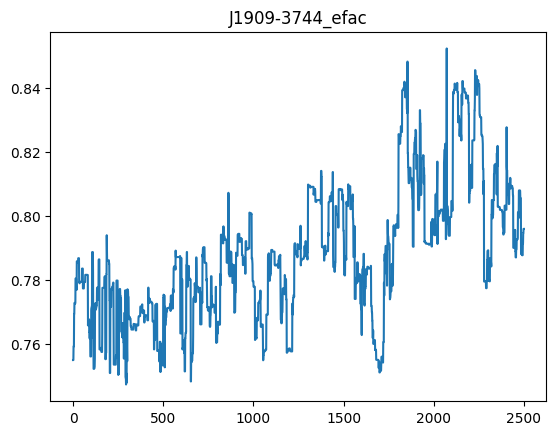

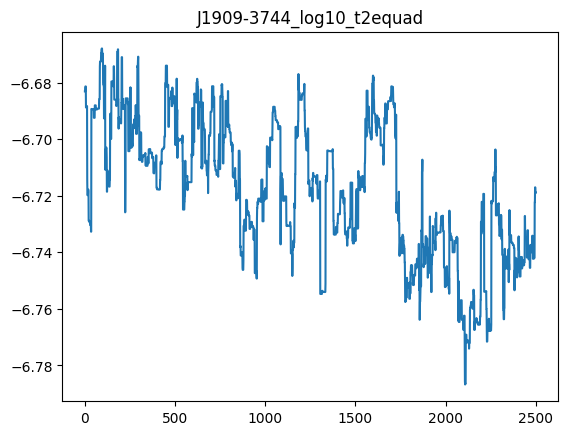

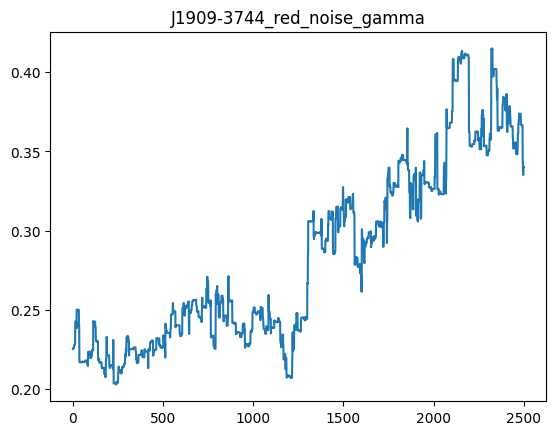

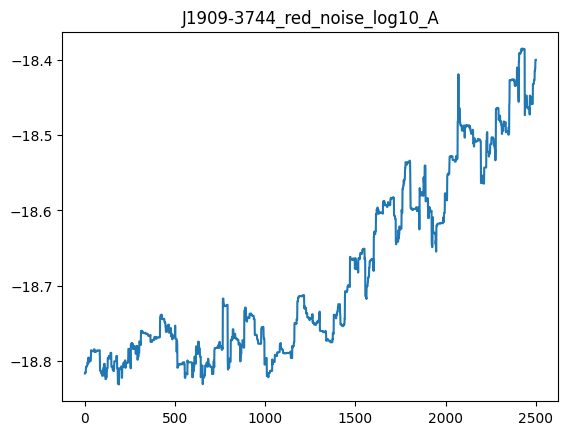

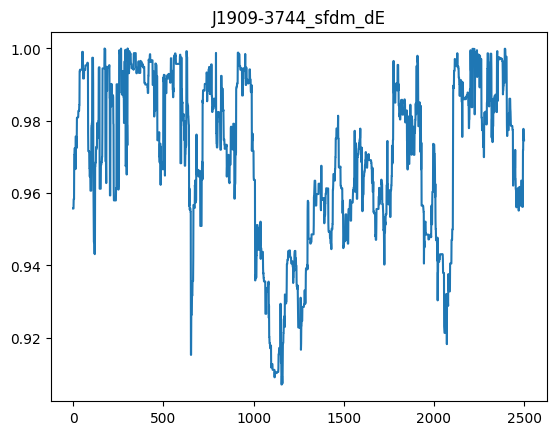

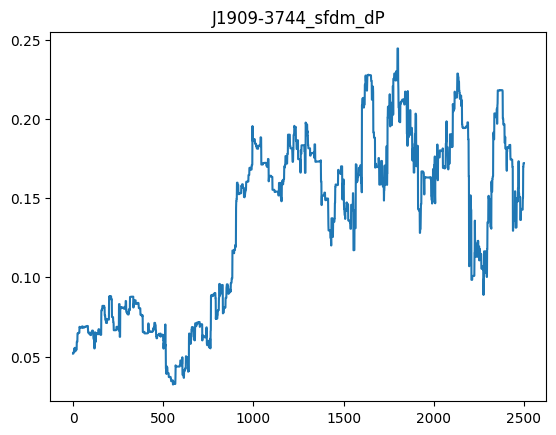

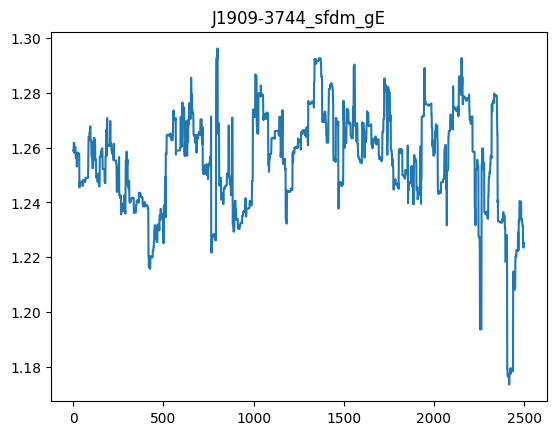

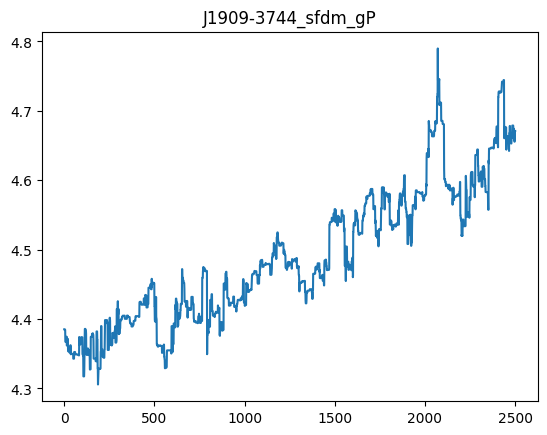

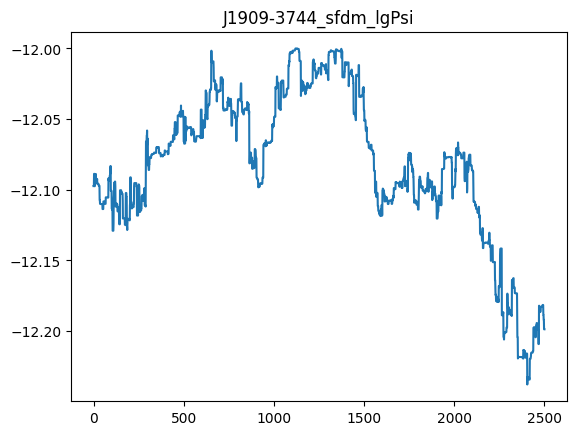

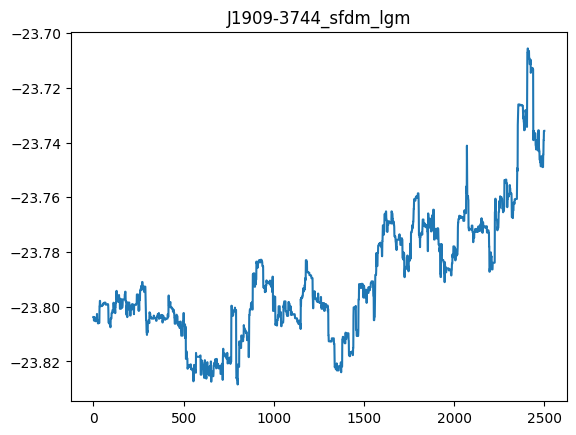

In [15]:
for i in range(len(pars)):
    plt.title(pars[i])
    plt.plot(ch[:,i])
    plt.show()

In [16]:
#last 4 columns are samplers
#print(ch.shape)  
#print(len(pars))

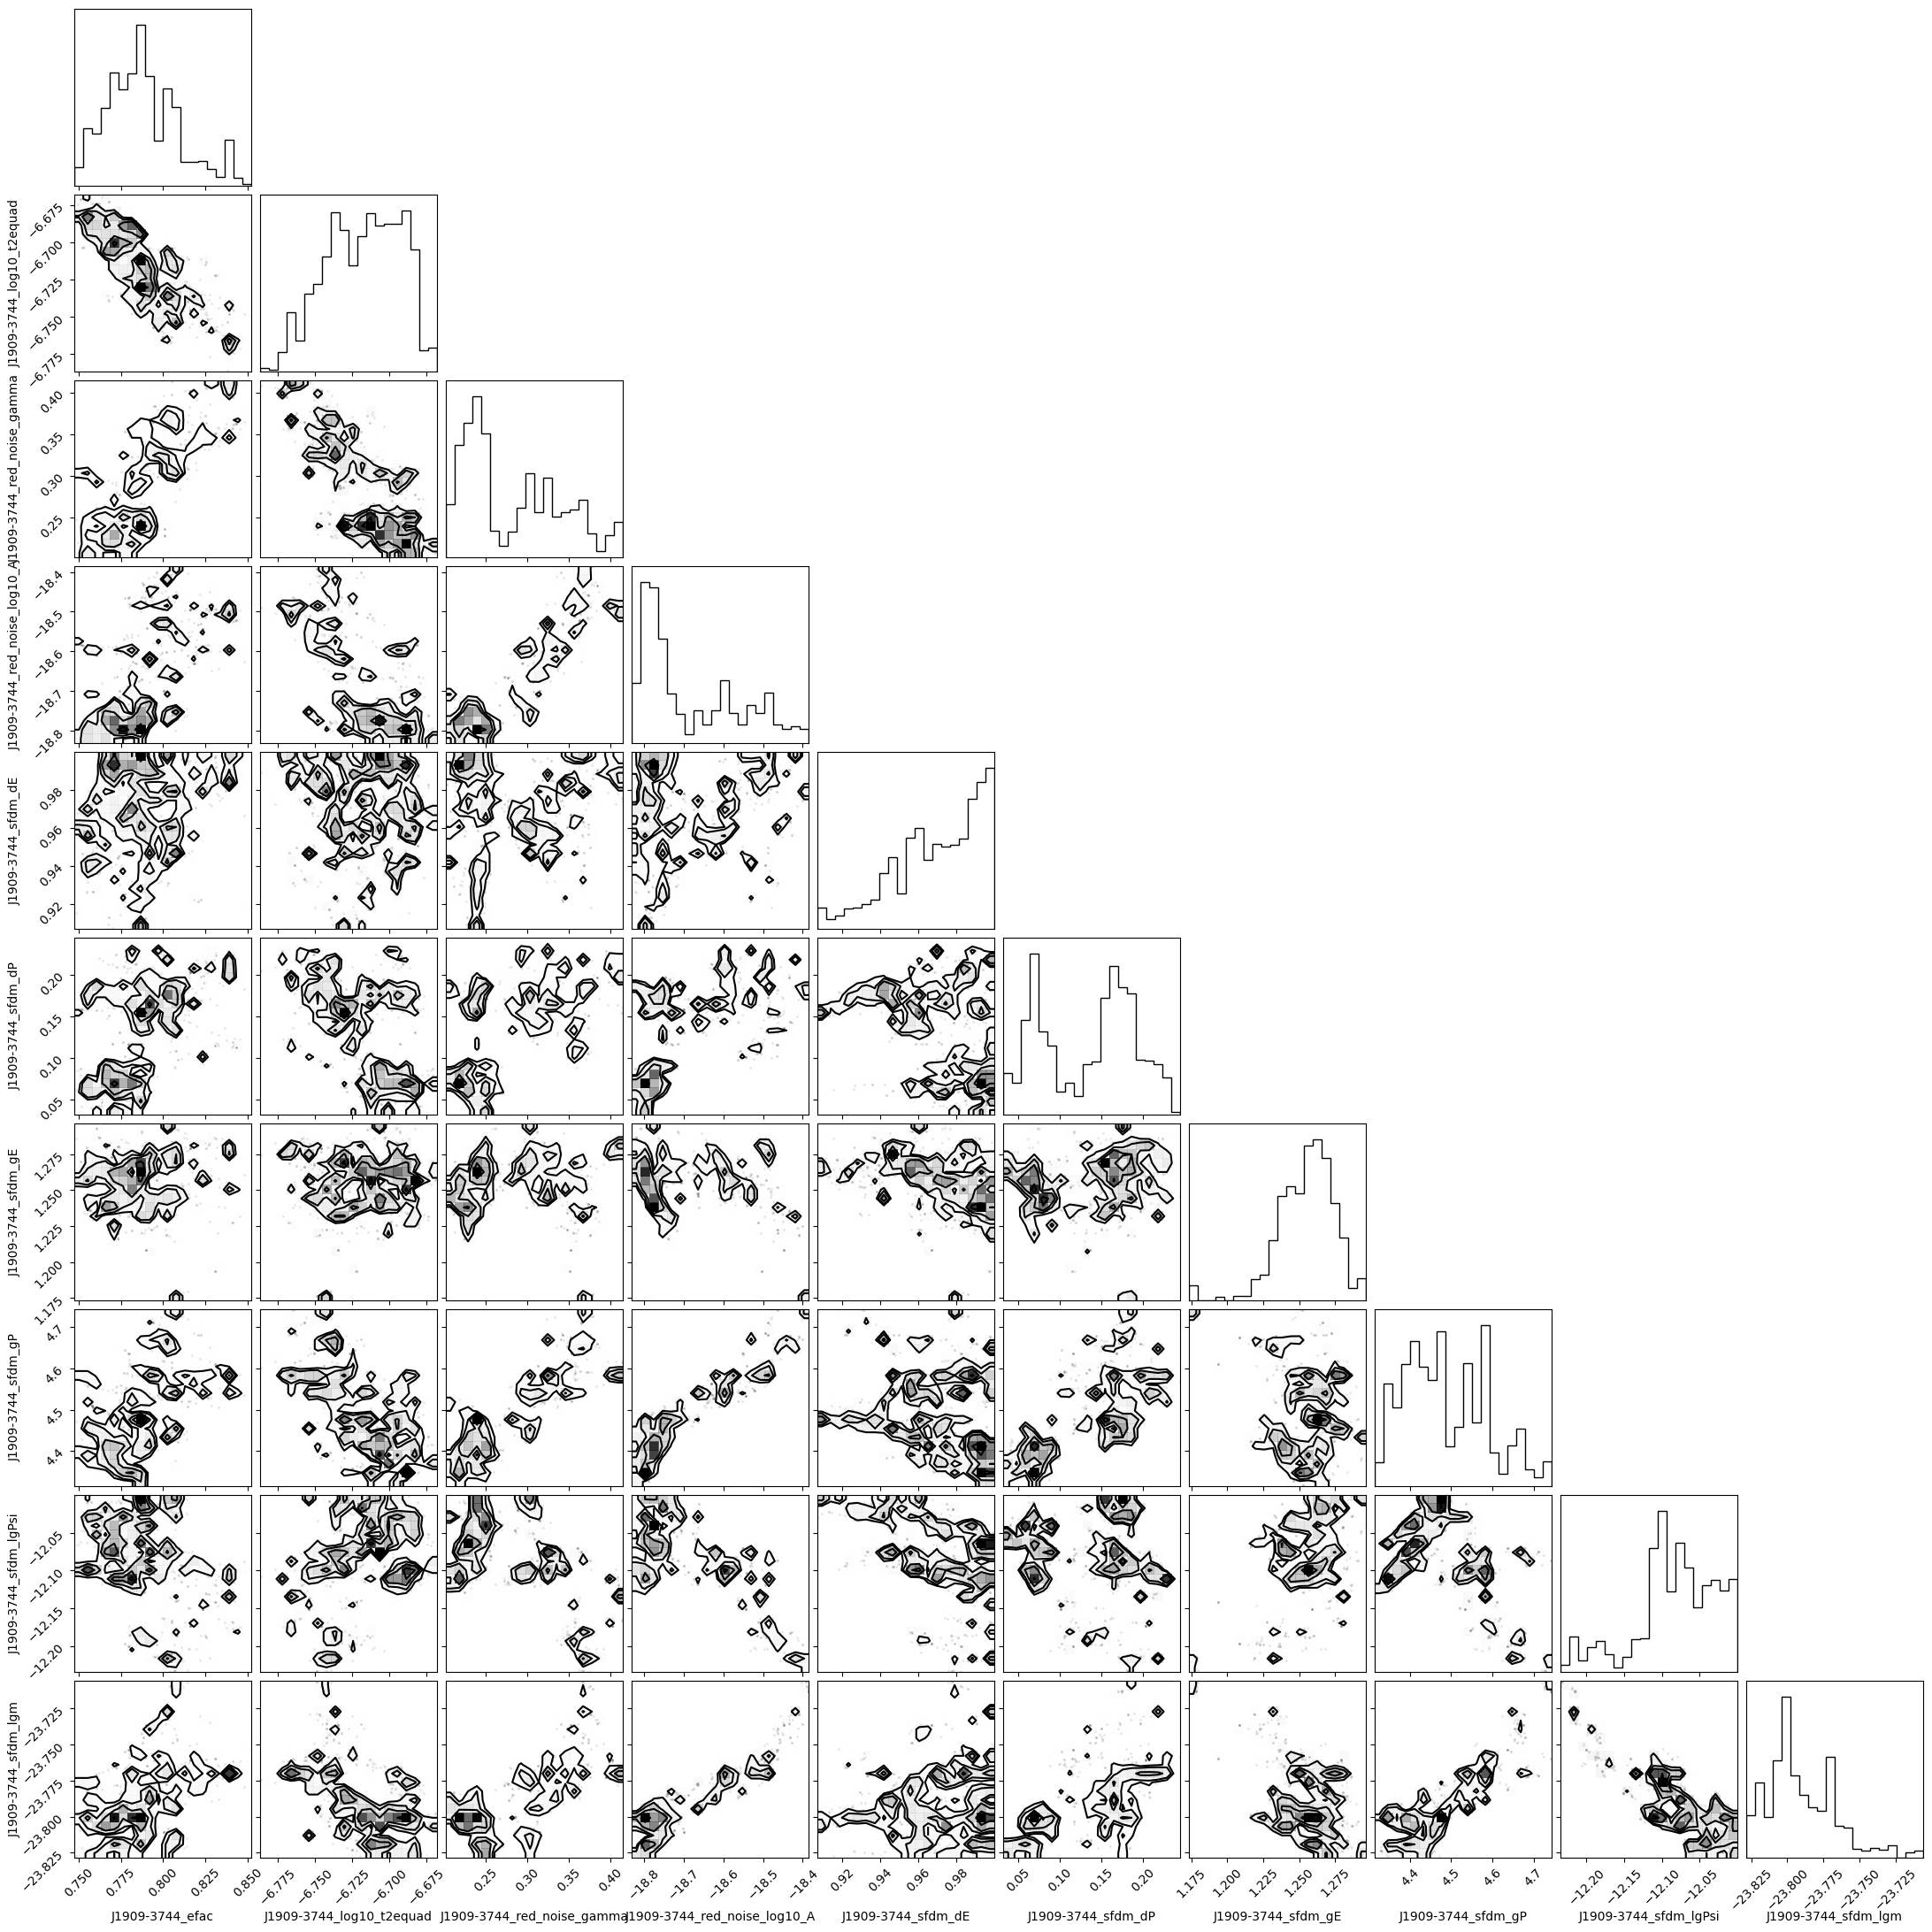

In [17]:
corner.corner(ch[::2, :-4], labels=pars, hist_kwargs={"density": True})
plt.show()

### Plot Psi vs m

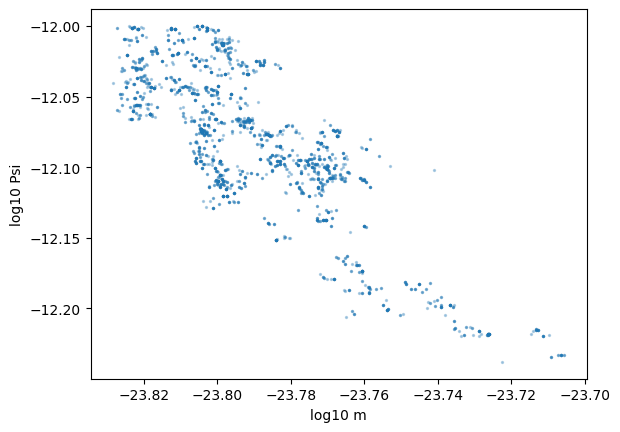

In [18]:
# find indices
i_psi = list(pars).index("J1909-3744_sfdm_lgPsi")
i_m   = list(pars).index("J1909-3744_sfdm_lgm")

# plot
plt.scatter(ch[:, i_m], ch[:, i_psi], s=2, alpha=0.3)
plt.xlabel("log10 m")
plt.ylabel("log10 Psi")
plt.show()